In [3]:
%matplotlib inline

import cosima_cookbook as cc
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client
import matplotlib.path as mpath
import datetime as dt

In [4]:
def collect_data(var, local_path, region, start_date, end_date):

    var_arr  = []

    cleaned_list = [item for item in local_path if item != []]

    for item,file in enumerate(cleaned_list):

        print(f'reading file: {file.split("/")[-1]}, {item+1}/{len(cleaned_list)}')
        sys.stdout.flush()
        
        with xr.open_dataset(file,decode_timedelta=False) as ds:

            time_range = ds['time'].sel(time=slice(start_date, end_date))


            data = ds[var].sel(time=time_range,\
                            yt_ocean=slice(region[0][0], region[0][1]), \
                            xt_ocean=slice(region[1][0], region[1][1])).load()

            data = data - 273.15
            data = data.mean(dim=["yt_ocean", "xt_ocean"]) 

        data.attrs['units'] = "°C"  

        var_arr.append(data)

    return  var_arr
    

In [5]:
client = Client()
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/35571/status,
Dashboard: /proxy/35571/status,Workers: 4
Total threads: 8,Total memory: 100.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34501,Workers: 4
Dashboard: /proxy/35571/status,Total threads: 8
Started: Just now,Total memory: 100.00 GiB
Comm: tcp://127.0.0.1:39419,Total threads: 2
Dashboard: /proxy/33215/status,Memory: 25.00 GiB
Nanny: tcp://127.0.0.1:40559,


--------------------------------------------------------------------------
but there are no active ports detected (or Open MPI was unable to use
them).  This is most certainly not what you wanted.  Check your
cables, subnet manager configuration, etc.  The openib BTL will be
ignored for this job.

  Local host: gadi-cpu-clx-0529
--------------------------------------------------------------------------


Starting ACCESS-OM2 SOTS TEMP analysis....
Processing temp variable...
Scattering path for temp...
reading file: ocean-3d-temp-1-monthly-mean-ym_2004_01.nc, 1/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2004_04.nc, 2/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2004_07.nc, 3/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2004_10.nc, 4/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2005_01.nc, 5/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2005_04.nc, 6/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2005_07.nc, 7/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2005_10.nc, 8/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2006_01.nc, 9/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2006_04.nc, 10/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2006_07.nc, 11/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2006_10.nc, 12/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2007_01.nc, 13/60
reading file: ocean-3d-temp-1-monthly-mean-ym_2007_04.nc, 14/60
reading file: 

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'numpy'


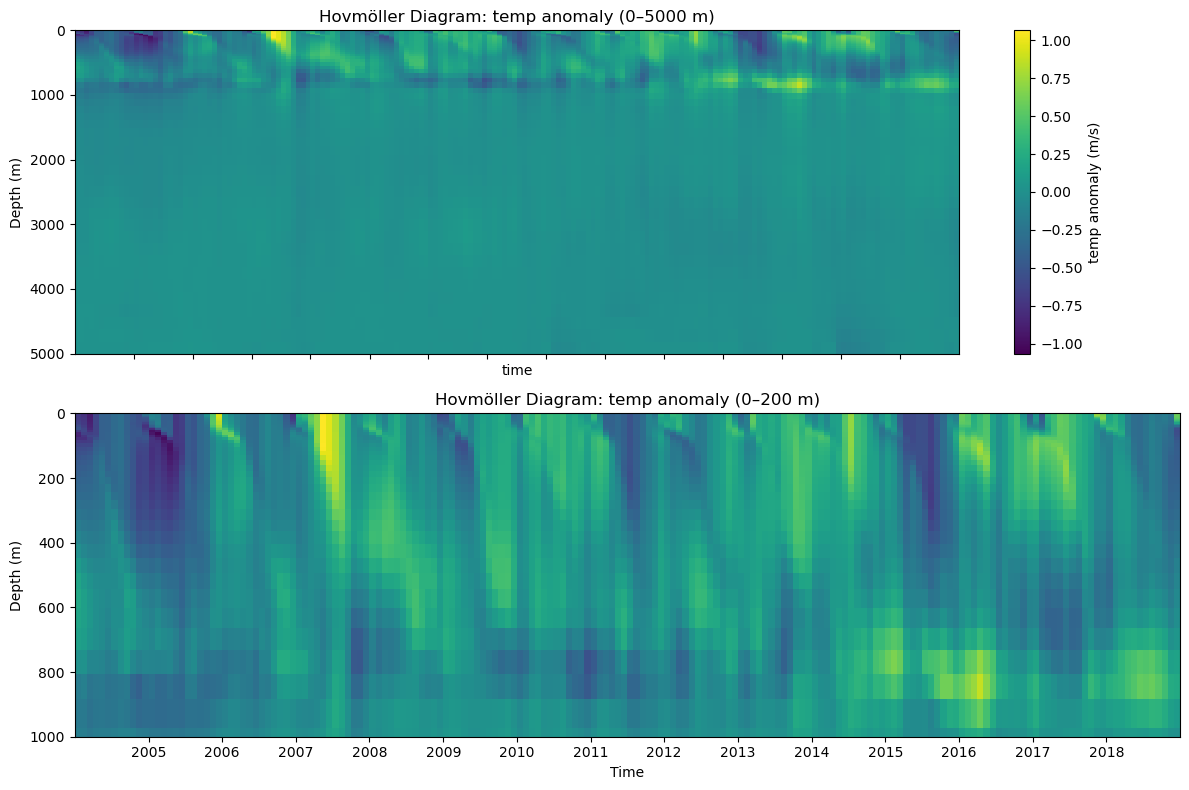

In [6]:
import os
import re
import sys
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client


catalog = intake.cat.access_nri


print('Starting ACCESS-OM2 SOTS TEMP analysis....')
sys.stdout.flush()

clim_start = 2004
clim_end = 2018

start_date = np.datetime64("2004-01-01")
end_date = np.datetime64("2018-12-31")

var   =  'temp'

access_model='01deg_jra55v140_iaf'
deg = '01deg'


region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([145,150])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]


#----------------------------------------------------------------------------------------------
# This section collects all the variable paths
#----------------------------------------------------------------------------------------------
path_dict = {var: []}


catalog_filtered = catalog[access_model].search(
    variable=var,
    frequency='1mon',
    realm='ocean',
    
)

df = catalog_filtered.df[
    (catalog_filtered.df['start_date'] >= '2004-01-01') & 
    (catalog_filtered.df['start_date'] <= '2018-12-31') &
    (catalog_filtered.df['filename'].str.contains('mean'))
]

file_list = df['path'].tolist()

path_dict[var].extend(file_list)
path_dict[var].sort(key=lambda f: tuple(map(int, re.search(r'ym_(\d{4})_(\d{2})', f).groups())))


print(f'Processing {var} variable...')
sys.stdout.flush()

    
path_list = path_dict[var]

print(f'Scattering path for {var}...')
sys.stdout.flush()
    

local_var = collect_data(var, path_list, region, start_date, end_date)

local_var = xr.concat(local_var, dim='time')

monthly_climatology = local_var.groupby('time.month').mean('time')

anomaly = local_var.groupby('time.month') - monthly_climatology

units = local_var.attrs.get("units", "")

anomaly.attrs['units'] = units

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

anomaly.plot(
    ax=axes[0],
    x='time',
    y='st_ocean',
    cmap='viridis',
    yincrease=False,
    cbar_kwargs={'label': f'{var} anomaly (m/s)'}
)
axes[0].set_title(f"Hovmöller Diagram: {var} anomaly (0–5000 m)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_ylim(5000, 0)

anomaly.plot(
    ax=axes[1],
    x='time',
    y='st_ocean',
    cmap='viridis',
    yincrease=False,
    add_colorbar=False  
)
axes[1].set_title(f"Hovmöller Diagram: {var} anomaly (0–200 m)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_xlabel("Time")
axes[1].set_ylim(1000, 0)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()
